# FIT5149 Assessment 1: Sanctioned Loan Amount Prediction

This notebook starts the assessment from a clean implementation. It establishes the condition of the supplied data, records reproducible evidence for cleaning decisions, constructs lending-related features, and compares three regression model families with the same cross-validation folds.

This is a **model-development notebook**, not yet the final packaged implementation. The Kaggle submission is deliberately postponed until the final model has been selected using internal validation.

## Workflow

1. Load and validate the supplied files.
2. Investigate missing values, sentinel codes, impossible values, redundancy, and the target structure.
3. Define deterministic feature engineering.
4. Compare Ridge, Random Forest, and Histogram Gradient Boosting regression.
5. Diagnose out-of-fold errors and decide the next experiments.

In [5]:
from pathlib import Path
import os
import platform
import sys
import time
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "sanctioned_amount_aud"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

np.random.seed(RANDOM_STATE)

## 1. Load the supplied data

The notebook uses paths relative to its own folder. This avoids machine-specific absolute paths and makes the final implementation easier to reproduce.

In [6]:
DATA_DIR = Path.cwd()
if not (DATA_DIR / "training_set.csv").exists():
    candidate = Path.cwd() / "Assignment" / "A1"
    if (candidate / "training_set.csv").exists():
        DATA_DIR = candidate

train = pd.read_csv(DATA_DIR / "training_set.csv")
test = pd.read_csv(DATA_DIR / "kaggle_test_X.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Kaggle test:  {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Submission:   {sample_submission.shape[0]:,} rows x {sample_submission.shape[1]} columns")

Training data: 19,322 rows x 29 columns
Kaggle test:  10,000 rows x 28 columns
Submission:   10,000 rows x 2 columns


## 2. File and schema integrity checks

These checks fail early if a supplied file is missing, the row order no longer matches the submission template, or identifiers are duplicated. `application_id` is retained for the final output but excluded from predictors, as required by the data dictionary.

In [7]:
expected_train_shape = (19_322, 29)
expected_test_shape = (10_000, 28)

assert train.shape == expected_train_shape
assert test.shape == expected_test_shape
assert TARGET in train.columns and TARGET not in test.columns
assert train.drop(columns=TARGET).columns.tolist() == test.columns.tolist()
assert train["application_id"].is_unique
assert test["application_id"].is_unique
assert test["application_id"].equals(sample_submission["application_id"])
assert sample_submission.columns.tolist() == ["application_id", TARGET]
assert train["application_id"].str.fullmatch(r"LN-\d{6}").all()
assert test["application_id"].str.fullmatch(r"LN-\d{6}").all()

train_dates = pd.to_datetime(train["application_date"], format="%d/%m/%Y", errors="raise")
test_dates = pd.to_datetime(test["application_date"], format="%d/%m/%Y", errors="raise")

print("All schema and identifier checks passed.")
print(f"Training date range: {train_dates.min().date()} to {train_dates.max().date()}")
print(f"Test date range:     {test_dates.min().date()} to {test_dates.max().date()}")

All schema and identifier checks passed.
Training date range: 2023-01-01 to 2024-12-30
Test date range:     2023-01-01 to 2024-12-30


## 3. Data quality investigation

The marking guide rewards evidence about the actual dataset rather than a generic checklist. The following audit measures missingness, cardinality, and coded sentinel values for every variable.

In [8]:
quality_audit = pd.DataFrame(
    {
        "dtype": train.dtypes.astype(str),
        "missing_n": train.isna().sum(),
        "missing_pct": 100 * train.isna().mean(),
        "unique_including_missing": train.nunique(dropna=False),
    }
)

numeric_columns_raw = train.select_dtypes(include="number").columns
quality_audit["sentinel_minus_999_n"] = [
    int((train[column] == -999).sum()) if column in numeric_columns_raw else 0
    for column in quality_audit.index
]

quality_audit.sort_values(
    ["missing_pct", "sentinel_minus_999_n"], ascending=False
).style.format({"missing_pct": "{:.2f}%"})

,dtype,missing_n,missing_pct,unique_including_missing,sentinel_minus_999_n
property_age_years,float64,6260,32.40%,12773,0
monthly_income_aud,float64,4963,25.69%,12331,0
annual_income_aud,float64,4848,25.09%,14151,0
employment_sector,str,4706,24.36%,19,0
credit_rating,float64,3953,20.46%,11646,0
existing_repayments_aud,float64,2294,11.87%,14910,100
dependants_count,float64,1576,8.16%,10,0
property_value_aud,float64,1178,6.10%,17943,199
income_consistency,str,1077,5.57%,3,0
property_area,str,219,1.13%,4,0


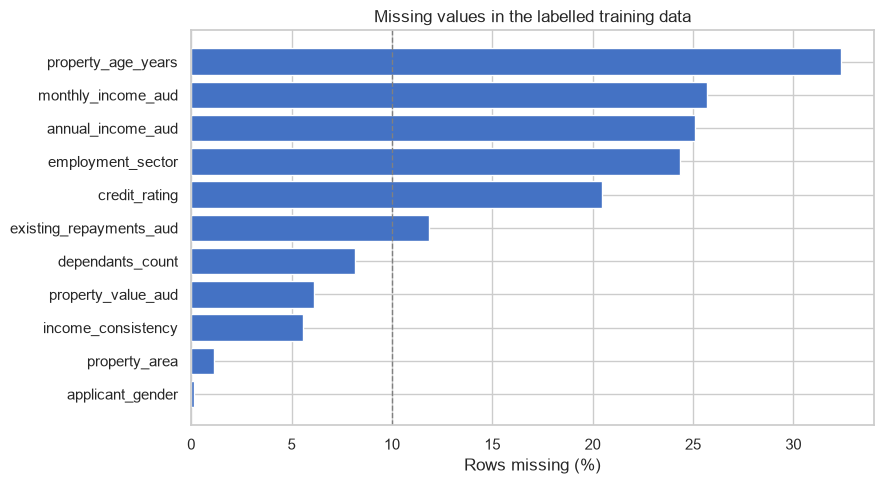

In [9]:
missing_plot = quality_audit.query("missing_n > 0").sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(missing_plot.index, missing_plot["missing_pct"], color="#4472C4")
ax.set(title="Missing values in the labelled training data", xlabel="Rows missing (%)", ylabel="")
ax.axvline(10, color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [11]:
categorical_columns_raw = [
    column
    for column in train.select_dtypes(include=["object"]).columns
    if column not in ["application_id", "application_date"]
]

category_summary = []
for column in categorical_columns_raw:
    train_levels = set(train[column].dropna().unique())
    test_levels = set(test[column].dropna().unique())
    category_summary.append(
        {
            "feature": column,
            "train_levels": len(train_levels),
            "test_levels": len(test_levels),
            "train_only_levels": sorted(train_levels - test_levels),
            "test_only_levels": sorted(test_levels - train_levels),
            "rarest_train_level_n": int(train[column].value_counts().min()),
        }
    )

pd.DataFrame(category_summary)

/var/folders/bj/0_hb0msn50q45nr4br97h54w0000gn/T/ipykernel_74139/745405371.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in train.select_dtypes(include=["object"]).columns


,feature,train_levels,test_levels,train_only_levels,test_only_levels,rarest_train_level_n
0,applicant_gender,2,2,[],[],9608
1,income_consistency,2,2,[],[],1674
2,occupation_class,8,4,"[no_employment, parental_leave, proprietor, st...",[],1
3,employment_sector,18,18,[],[],47
4,residence_area,3,3,[],[],1994
5,expense_flag_a,2,2,[],[],6935
6,expense_flag_b,2,2,[],[],6370
7,card_status,4,4,[],[],980
8,property_category,4,4,[],[],4630
9,property_area,3,3,[],[],5996


### 3.1 Sentinel codes are missing values, not measurements

The value `-999` appears in variables that cannot meaningfully be negative. It is converted to missing before modelling. Imputation remains inside each model pipeline so that validation folds cannot influence their training folds.

In [12]:
SENTINEL_COLUMNS = [
    "existing_repayments_aud",
    "has_co_applicant",
    "property_value_aud",
]

sentinel_counts = pd.DataFrame(
    {
        "training_minus_999": [(train[column] == -999).sum() for column in SENTINEL_COLUMNS],
        "test_minus_999": [(test[column] == -999).sum() for column in SENTINEL_COLUMNS],
    },
    index=SENTINEL_COLUMNS,
)
sentinel_counts

,training_minus_999,test_minus_999
existing_repayments_aud,100,50
has_co_applicant,107,53
property_value_aud,199,110


### 3.2 `property_age_years` is not a plausible property age

This is the most important data-quality finding. Every row with both `property_age_years` and `annual_income_aud` present contains exactly the same value in the two columns, and no recorded property age is 200 years or less. The field is therefore treated as a corrupted duplicate of annual income, not as property age.

The feature-engineering function uses it only as a backup observation for annual income, records income-source availability, and then drops the misleading raw field. This decision should later be tested with an ablation study.

In [13]:
income_property_overlap = train[["annual_income_aud", "property_age_years"]].dropna()
exact_matches = np.isclose(
    income_property_overlap["annual_income_aud"],
    income_property_overlap["property_age_years"],
    rtol=0,
    atol=0.001,
)

income_month_overlap = train[["annual_income_aud", "monthly_income_aud"]].dropna()
annual_to_monthly_ratio = (
    income_month_overlap["annual_income_aud"]
    / income_month_overlap["monthly_income_aud"]
)

data_quality_evidence = pd.Series(
    {
        "rows where annual income and property age both exist": len(income_property_overlap),
        "exact matches between those two fields": int(exact_matches.sum()),
        "plausible property ages between 0 and 200": int(train["property_age_years"].between(0, 200).sum()),
        "correlation of annual and monthly income": income_month_overlap.corr().iloc[0, 1],
        "median annual/monthly income ratio": annual_to_monthly_ratio.median(),
    }
)
data_quality_evidence

rows where annual income and property age both exist   11,524.000
exact matches between those two fields                 11,524.000
plausible property ages between 0 and 200                   0.000
correlation of annual and monthly income                    1.000
median annual/monthly income ratio                         11.999
dtype: float64

## 4. Target investigation

RMSE is sensitive to large errors, so the scale and structure of the target matter. Here, 26.8% of labelled applications have zero sanctioned amount. For every row, the sanctioned amount is no greater than the requested amount.

More unusually, the sanctioned amount is almost exactly a fixed proportion of the requested amount. The observed proportions are 0%, 65%, 70%, 75%, 80%, 85%, 90%, and 100%. This suggests a tiered underwriting decision. It motivates stratifying validation folds by sanction tier and testing a rate-based model later, while the initial comparison below remains a direct regression on AUD.

In [14]:
y = train[TARGET].copy()
requested = train["requested_amount_aud"]
sanction_rate = (y / requested).round(2)

target_checks = pd.Series(
    {
        "zero_target_n": int((y == 0).sum()),
        "zero_target_pct": 100 * (y == 0).mean(),
        "sanction_above_request_n": int((y > requested).sum()),
        "unique_rounded_sanction_rates": sorted(sanction_rate.unique().tolist()),
    }
)
target_checks

zero_target_n                                                           5177
zero_target_pct                                                       26.793
sanction_above_request_n                                                   0
unique_rounded_sanction_rates    [0.0, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
dtype: object

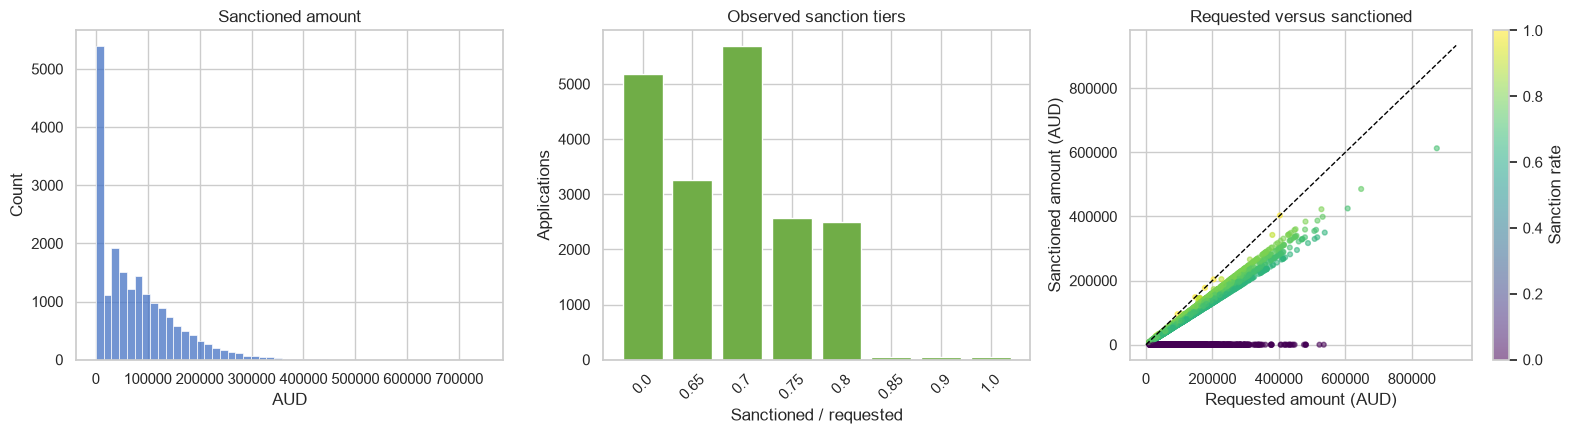

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(y, bins=50, ax=axes[0], color="#4472C4")
axes[0].set(title="Sanctioned amount", xlabel="AUD")

rate_counts = sanction_rate.value_counts().sort_index()
axes[1].bar(rate_counts.index.astype(str), rate_counts.values, color="#70AD47")
axes[1].set(title="Observed sanction tiers", xlabel="Sanctioned / requested", ylabel="Applications")
axes[1].tick_params(axis="x", rotation=45)

sample_for_plot = train.sample(n=min(4_000, len(train)), random_state=RANDOM_STATE)
sample_rate = (sample_for_plot[TARGET] / sample_for_plot["requested_amount_aud"]).round(2)
scatter = axes[2].scatter(
    sample_for_plot["requested_amount_aud"],
    sample_for_plot[TARGET],
    c=sample_rate,
    cmap="viridis",
    s=12,
    alpha=0.55,
)
axes[2].plot([0, requested.max()], [0, requested.max()], color="black", linestyle="--", linewidth=1)
axes[2].set(title="Requested versus sanctioned", xlabel="Requested amount (AUD)", ylabel="Sanctioned amount (AUD)")
fig.colorbar(scatter, ax=axes[2], label="Sanction rate")

plt.tight_layout()
plt.show()

## 5. Deterministic cleaning and feature engineering

Only transformations that do not learn from other rows are performed before cross-validation. All learned steps, including imputation, scaling, and category encoding, remain inside the pipelines.

The constructed features reflect lending decisions:

- requested amount relative to property value;
- requested amount relative to reconciled annual income;
- existing repayments relative to reconciled monthly income;
- property value remaining after the requested loan;
- cyclical calendar position and application year;
- missingness and income-source consistency.

In [16]:
def engineer_features(frame):
    x = frame.copy()

    for column in SENTINEL_COLUMNS:
        x[column] = x[column].replace(-999, np.nan)

    x["missing_value_count"] = x.isna().sum(axis=1)

    application_date = pd.to_datetime(
        x.pop("application_date"), format="%d/%m/%Y", errors="raise"
    )
    x["application_year"] = application_date.dt.year
    x["application_month_sin"] = np.sin(2 * np.pi * application_date.dt.month / 12)
    x["application_month_cos"] = np.cos(2 * np.pi * application_date.dt.month / 12)
    x["application_dayofyear_sin"] = np.sin(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )
    x["application_dayofyear_cos"] = np.cos(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )

    income_candidates = pd.concat(
        [
            x["annual_income_aud"],
            12 * x["monthly_income_aud"],
            x["property_age_years"],
        ],
        axis=1,
    )
    x["annual_income_reconciled_aud"] = income_candidates.median(axis=1, skipna=True)
    x["income_sources_available"] = income_candidates.notna().sum(axis=1)
    x["income_relative_gap"] = (
        (x["annual_income_aud"] - 12 * x["monthly_income_aud"]).abs()
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    x["requested_to_property_value"] = (
        x["requested_amount_aud"] / x["property_value_aud"].replace(0, np.nan)
    )
    x["requested_to_annual_income"] = (
        x["requested_amount_aud"]
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )
    x["repayments_to_monthly_income"] = (
        x["existing_repayments_aud"]
        / (x["annual_income_reconciled_aud"] / 12).replace(0, np.nan)
    )
    x["property_value_minus_requested"] = (
        x["property_value_aud"] - x["requested_amount_aud"]
    )

    x = x.drop(columns=["application_id", "property_age_years"])

    # Treat the repeated internal reference as a category, not a continuous number.
    x["property_ref"] = x["property_ref"].astype("string")
    return x


X = engineer_features(train.drop(columns=TARGET))
X_kaggle = engineer_features(test)

assert X.columns.tolist() == X_kaggle.columns.tolist()
assert not np.isinf(X.select_dtypes(include="number").to_numpy()).any()

print(f"Model matrix before learned preprocessing: {X.shape}")
print(f"Reconciled income remains missing for {X['annual_income_reconciled_aud'].isna().sum():,} rows")
X.head()

Model matrix before learned preprocessing: (19322, 38)
Reconciled income remains missing for 3,195 rows


,applicant_gender,applicant_age,annual_income_aud,income_consistency,occupation_class,employment_sector,residence_area,requested_amount_aud,existing_repayments_aud,expense_flag_a,expense_flag_b,dependants_count,credit_rating,prior_default_count,card_status,property_ref,property_category,property_area,has_co_applicant,property_value_aud,marketing_channel,branch_id,monthly_income_aud,risk_review_flag,enquiry_count_12m,missing_value_count,application_year,application_month_sin,application_month_cos,application_dayofyear_sin,application_dayofyear_cos,annual_income_reconciled_aud,income_sources_available,income_relative_gap,requested_to_property_value,requested_to_annual_income,repayments_to_monthly_income,property_value_minus_requested
0,male,65,"3,572.420",steady,retiree,NaN,outer_metro,"80,823.310",369.810,no,yes,NaN,806.520,1,current,77,cat_c,NaN,1.000,"118,370.540",online,BR111,290.870,1,3,3,2024,-0.500,0.866,-0.497,0.868,"3,572.420",3,0.023,0.683,22.624,1.242,"37,547.230"
1,male,48,NaN,variable,salaried,retail,outer_metro,"41,673.080",188.250,no,no,2.000,613.700,1,current,743,cat_b,regional,0.000,"47,000.080",online,BR110,NaN,0,4,3,2023,-1.000,-0.000,-0.995,-0.102,NaN,0,NaN,0.887,NaN,NaN,"5,327.000"
2,female,18,"3,551.480",variable,salaried,retail,outer_metro,"199,076.750",941.270,no,yes,2.000,780.280,0,current,788,cat_b,outer_metro,1.000,"277,686.300",online,BR164,286.620,0,4,1,2024,-1.000,-0.000,-0.958,-0.287,"3,495.460",2,0.032,0.717,56.953,3.231,"78,609.550"
3,male,50,NaN,variable,commercial_partner,retail,inner_metro,"120,176.890",309.710,no,yes,2.000,NaN,0,none_held,709,cat_a,outer_metro,1.000,"203,173.220",online,BR051,NaN,1,3,4,2023,-0.500,-0.866,-0.391,-0.920,NaN,0,NaN,0.591,NaN,NaN,"82,996.330"
4,male,28,NaN,NaN,salaried,NaN,outer_metro,"62,745.530",454.490,no,no,NaN,NaN,0,current,772,cat_d,regional,1.000,"86,636.210",branch_walkin,BR072,NaN,1,2,7,2024,-0.000,1.000,-0.292,0.956,NaN,0,NaN,0.724,NaN,NaN,"23,890.680"


## 6. Validation design

The Kaggle public leaderboard uses only 2,000 rows and must not be used as a validation set. This notebook uses five shuffled folds with a fixed seed. Folds are stratified by the eight observed sanction tiers, which keeps the zero-sanction and rarer high-rate regimes represented in every fold.

The same precomputed folds are used for every model, enabling paired comparisons. Preprocessing is fitted separately inside each training fold, preventing leakage from imputation, scaling, or encoding.

In [17]:
strata = sanction_rate.map(lambda value: f"{value:.2f}")
splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds = list(splitter.split(X, strata))

fold_balance = []
for fold_number, (_, valid_index) in enumerate(folds, start=1):
    counts = strata.iloc[valid_index].value_counts(normalize=True).sort_index()
    fold_balance.append(counts.rename(f"fold_{fold_number}"))

pd.concat(fold_balance, axis=1).T.style.format("{:.2%}")

,0.00,0.65,0.70,0.75,0.80,0.85,0.90,1.00
fold_1,26.78%,16.84%,29.44%,13.30%,12.94%,0.23%,0.26%,0.21%
fold_2,26.80%,16.87%,29.42%,13.27%,12.94%,0.23%,0.26%,0.21%
fold_3,26.81%,16.87%,29.43%,13.28%,12.94%,0.21%,0.26%,0.21%
fold_4,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%
fold_5,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%


## 7. Preprocessing pipelines and candidate models

The model families are genuinely different:

1. **Ridge regression** is a regularised linear baseline. Numeric inputs are median-imputed and standardised; categorical inputs are imputed and one-hot encoded.
2. **Random Forest regression** captures interactions and nonlinear thresholds through bagged trees.
3. **Histogram Gradient Boosting regression** builds trees sequentially to correct earlier errors and treats encoded categorical columns as categorical features.

Rare categorical levels are handled explicitly. This matters because four occupation labels appear only one or two times in training and do not appear in the Kaggle test set.

In [18]:
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = [column for column in X.columns if column not in categorical_features]

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=10,
                            sparse_output=True,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            max_categories=254,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

categorical_mask_after_ordinal = (
    [False] * len(numeric_features) + [True] * len(categorical_features)
)

models = {
    "Ridge": Pipeline(
        steps=[
            ("preprocess", linear_preprocessor),
            ("model", Ridge(alpha=10.0)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", ordinal_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    min_samples_leaf=2,
                    max_features=0.8,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Histogram Gradient Boosting": Pipeline(
        steps=[
            ("preprocess", ordinal_preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=categorical_mask_after_ordinal,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("Candidate families:", ", ".join(models))

Numeric features: 25
Categorical features: 13
Candidate families: Ridge, Random Forest, Histogram Gradient Boosting


## 8. Five-fold model comparison

For each validation fold, the notebook reports raw RMSE and a business-consistent constrained RMSE. The constraint clips predictions to the interval from zero to the requested amount, matching every labelled observation. Model selection should consider both the mean error and its variation across folds.

In [19]:
def rmse(actual, predicted):
    return mean_squared_error(actual, predicted) ** 0.5


validation_rows = []
oof_predictions = {}
requested_array = train["requested_amount_aud"].to_numpy()

heuristic_prediction = 0.70 * requested_array
print(f"Simple 70% of requested heuristic RMSE: ${rmse(y, heuristic_prediction):,.0f}")

for model_name, model in models.items():
    started = time.time()
    oof_raw = np.full(len(train), np.nan)
    oof_constrained = np.full(len(train), np.nan)

    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
        fitted_model = clone(model)
        fitted_model.fit(X.iloc[train_index], y.iloc[train_index])

        raw_prediction = fitted_model.predict(X.iloc[valid_index])
        constrained_prediction = np.clip(
            raw_prediction,
            0,
            requested_array[valid_index],
        )

        oof_raw[valid_index] = raw_prediction
        oof_constrained[valid_index] = constrained_prediction
        validation_rows.append(
            {
                "model": model_name,
                "fold": fold_number,
                "raw_rmse_aud": rmse(y.iloc[valid_index], raw_prediction),
                "constrained_rmse_aud": rmse(
                    y.iloc[valid_index], constrained_prediction
                ),
                "prediction_below_zero_n": int((raw_prediction < 0).sum()),
                "prediction_above_request_n": int(
                    (raw_prediction > requested_array[valid_index]).sum()
                ),
            }
        )

    oof_predictions[model_name] = oof_constrained
    print(f"Finished {model_name} in {time.time() - started:.1f} seconds")

validation_detail = pd.DataFrame(validation_rows)
validation_summary = (
    validation_detail.groupby("model")
    .agg(
        mean_raw_rmse_aud=("raw_rmse_aud", "mean"),
        sd_raw_rmse_aud=("raw_rmse_aud", "std"),
        mean_constrained_rmse_aud=("constrained_rmse_aud", "mean"),
        sd_constrained_rmse_aud=("constrained_rmse_aud", "std"),
        predictions_below_zero=("prediction_below_zero_n", "sum"),
        predictions_above_request=("prediction_above_request_n", "sum"),
    )
    .sort_values("mean_constrained_rmse_aud")
)

validation_summary.style.format(
    {
        "mean_raw_rmse_aud": "${:,.0f}",
        "sd_raw_rmse_aud": "${:,.0f}",
        "mean_constrained_rmse_aud": "${:,.0f}",
        "sd_constrained_rmse_aud": "${:,.0f}",
    }
)

Simple 70% of requested heuristic RMSE: $55,448
Finished Ridge in 0.9 seconds
Finished Random Forest in 17.8 seconds
Finished Histogram Gradient Boosting in 5.1 seconds


,mean_raw_rmse_aud,sd_raw_rmse_aud,mean_constrained_rmse_aud,sd_constrained_rmse_aud,predictions_below_zero,predictions_above_request
model,,,,,,
Random Forest,"$36,047","$1,454","$36,046","$1,454",0,6
Histogram Gradient Boosting,"$36,066","$1,322","$36,049","$1,323",226,228
Ridge,"$50,216","$13,364","$43,310",$888,1371,944


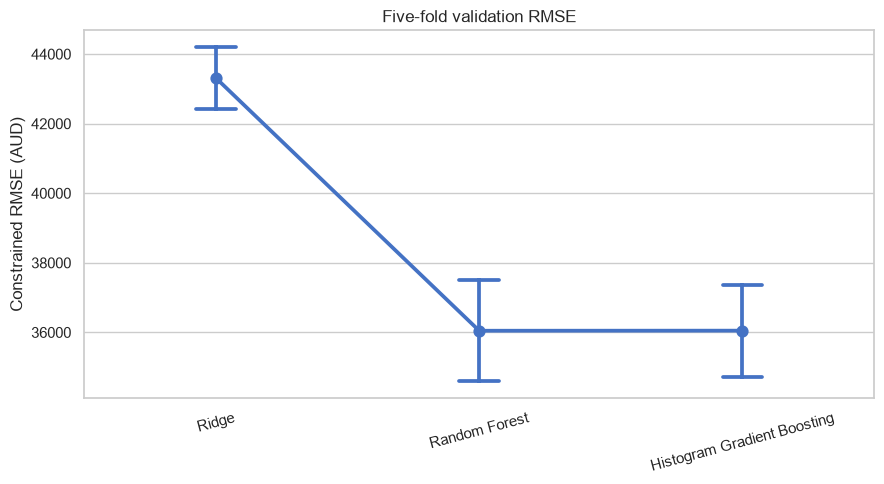

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.pointplot(
    data=validation_detail,
    x="model",
    y="constrained_rmse_aud",
    errorbar="sd",
    capsize=0.15,
    color="#4472C4",
    ax=ax,
)
ax.set(title="Five-fold validation RMSE", xlabel="", ylabel="Constrained RMSE (AUD)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 9. Out-of-fold error diagnosis

The best initial candidate is selected only for diagnosis. It is **not yet declared the final model**. Out-of-fold predictions provide an honest view of where the current approach fails without reusing training predictions.

In [21]:
best_initial_model = validation_summary.index[0]
best_oof = oof_predictions[best_initial_model]

diagnostics = train[[
    "requested_amount_aud",
    "risk_review_flag",
    "credit_rating",
]].copy()
diagnostics["sanction_rate"] = sanction_rate
diagnostics["actual"] = y
diagnostics["prediction"] = best_oof
diagnostics["residual"] = diagnostics["actual"] - diagnostics["prediction"]
diagnostics["absolute_error"] = diagnostics["residual"].abs()
diagnostics["request_size_band"] = pd.qcut(
    diagnostics["requested_amount_aud"],
    q=5,
    duplicates="drop",
)

error_by_tier = (
    diagnostics.groupby("sanction_rate", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "n": len(group),
                "rmse_aud": rmse(group["actual"], group["prediction"]),
                "mean_error_aud": group["residual"].mean(),
            }
        ),
        include_groups=False,
    )
)

error_by_request_band = (
    diagnostics.groupby("request_size_band", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "n": len(group),
                "rmse_aud": rmse(group["actual"], group["prediction"]),
                "mean_absolute_error_aud": group["absolute_error"].mean(),
            }
        ),
        include_groups=False,
    )
)

print("Best initial candidate:", best_initial_model)
display(error_by_tier.style.format({"rmse_aud": "${:,.0f}", "mean_error_aud": "${:,.0f}"}))
display(error_by_request_band.style.format({"rmse_aud": "${:,.0f}", "mean_absolute_error_aud": "${:,.0f}"}))

Best initial candidate: Random Forest


,n,rmse_aud,mean_error_aud
sanction_rate,,,
0.000000,5177.000000,"$60,850","$-30,954"
0.650000,3257.000000,"$11,507","$6,592"
0.700000,5686.000000,"$16,307","$10,647"
0.750000,2568.000000,"$20,130","$14,249"
0.800000,2502.000000,"$29,856","$22,233"
0.850000,42.000000,"$82,762","$39,329"
0.900000,50.000000,"$68,658","$48,719"
1.000000,40.000000,"$76,174","$62,520"


,n,rmse_aud,mean_absolute_error_aud
request_size_band,,,
"(9467.479, 58154.086]",3865.000000,"$9,363","$5,538"
"(58154.086, 97642.096]",3864.000000,"$16,363","$9,755"
"(97642.096, 139523.094]",3864.000000,"$25,274","$15,193"
"(139523.094, 204700.392]",3864.000000,"$37,970","$23,344"
"(204700.392, 933695.43]",3865.000000,"$63,787","$36,423"


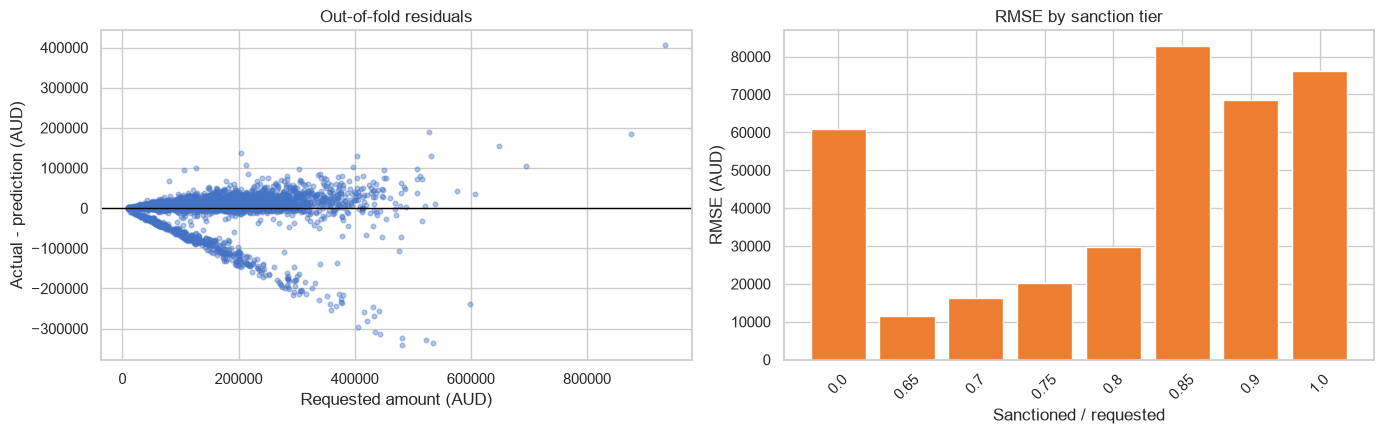

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sample_index = train.sample(n=min(5_000, len(train)), random_state=RANDOM_STATE).index
axes[0].scatter(
    diagnostics.loc[sample_index, "requested_amount_aud"],
    diagnostics.loc[sample_index, "residual"],
    s=11,
    alpha=0.4,
    color="#4472C4",
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title="Out-of-fold residuals", xlabel="Requested amount (AUD)", ylabel="Actual - prediction (AUD)")

plot_error_by_tier = error_by_tier.reset_index()
axes[1].bar(
    plot_error_by_tier["sanction_rate"].astype(str),
    plot_error_by_tier["rmse_aud"],
    color="#ED7D31",
)
axes[1].set(title="RMSE by sanction tier", xlabel="Sanctioned / requested", ylabel="RMSE (AUD)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 10. Next experiments before choosing the final model

The next iteration should remain driven by the same five folds:

1. **Ablate the corrupted income backup.** Compare dropping `property_age_years` completely with using it only as an income backup.
2. **Model the tiered target explicitly.** Compare direct AUD regression with sanction-rate regression and a probability-weighted tier model. Evaluate all predictions in AUD with RMSE.
3. **Tune only promising families.** Use a bounded random search for the strongest tree model instead of an exhaustive grid.
4. **Investigate high-cardinality identifiers.** Compare excluding `property_ref`, treating it as categorical, and a leakage-safe encoding fitted within each fold.
5. **Produce statistical evidence.** Use repeated permutation importance or bootstrap confidence intervals, Ridge coefficient uncertainty, and paired fold-level error differences. Do not rely on one feature-importance chart.
6. **Assess limitations.** Report error by requested-amount band, zero versus positive sanctions, target tier, missingness pattern, and time period.
7. **Only then retrain and submit.** Fit the selected pipeline on all 19,322 labelled rows, predict the 10,000 test rows, validate the exact two-column format, and save a new submission file without overwriting earlier experiments.

## 11. Reproducibility record

Record these versions in the final README, together with the command used to run the notebook or script.

In [23]:
versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "Platform": platform.platform(),
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "random_seed": RANDOM_STATE,
    }
)
versions

Python                               3.11.15
Platform        macOS-26.6.2-arm64-arm-64bit
NumPy                                  2.4.6
pandas                                 3.0.5
scikit-learn                           1.9.0
random_seed                               42
dtype: object